In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import pickle

In [128]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\midst\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\midst\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\midst\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [129]:
setwd = "D:/Sathish/AIML/Intelligent book recommendations/"
pd.set_option('display.max.columns',None)
pd.set_option('display.max_rows',None)

In [130]:
#Importing dataset
df_1 = pd.read_csv("Audible_Catlog.csv")
df_2 = pd.read_csv("Audible_Catlog_Advanced_Features.csv")

In [131]:
display(df_2.info())
print("\n")
display(df_1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          4464 non-null   object 
 1   Author             4464 non-null   object 
 2   Rating             4464 non-null   float64
 3   Number of Reviews  4043 non-null   float64
 4   Price              4464 non-null   int64  
 5   Description        4458 non-null   object 
 6   Listening Time     4464 non-null   object 
 7   Ranks and Genre    4464 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 279.1+ KB


None



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6368 entries, 0 to 6367
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          6368 non-null   object 
 1   Author             6368 non-null   object 
 2   Rating             6368 non-null   float64
 3   Number of Reviews  5737 non-null   float64
 4   Price              6365 non-null   float64
dtypes: float64(3), object(2)
memory usage: 248.9+ KB


None

In [132]:
df_1 = df_1.rename(columns={'Rating':'Comp_Rating','Number of Reviews':'Comp_no.of.reviews','Price':'Comp_Price'})

In [133]:
data = pd.merge(df_2,df_1,on=['Book Name','Author'],how='inner')

In [134]:
display(data.head())
print("\nLast six observations")
display(data.tail())

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre,Comp_Rating,Comp_no.of.reviews,Comp_Price
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,371.0,10080,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",4.9,313.0,10080.0
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3682.0,615,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",4.6,3658.0,615.0
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20306.0,10378,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",4.4,20174.0,10378.0
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4678.0,888,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top...",4.6,4614.0,888.0
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4308.0,1005,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top...",4.6,4302.0,1005.0



Last six observations


,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre,Comp_Rating,Comp_no.of.reviews,Comp_Price
4246,Passion and Purity: Learning to Bring Your Lov...,Elisabeth Elliot,4.8,156.0,608,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,4.8,153.0,608.0
4247,Things I Wish I'd Known Before We Got Married,Gary Chapman,4.7,1388.0,516,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,4.7,1379.0,516.0
4248,Things I Wish I'd Known Before We Got Married,Gary Chapman,4.7,1388.0,516,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,4.7,1379.0,516.0
4249,The Disease Delusion: Conquering the Causes of...,Dr. Jeffrey S. Bland,4.7,259.0,12356,Disease care vs health care: Which would you c...,-1,-1,4.7,256.0,12356.0
4250,The Disease Delusion: Conquering the Causes of...,Dr. Jeffrey S. Bland,4.7,259.0,12356,Disease care vs health care: Which would you c...,-1,-1,4.7,256.0,12356.0


In [135]:
data.drop_duplicates(inplace=True)

In [136]:
for i in data.columns:
    print(i)
    print(data[i].value_counts)
    print("\n")

Book Name
<bound method IndexOpsMixin.value_counts of 0       Think Like a Monk: The Secret of How to Harnes...
1       Ikigai: The Japanese Secret to a Long and Happ...
2       The Subtle Art of Not Giving a F*ck: A Counter...
3       Atomic Habits: An Easy and Proven Way to Build...
4       Life's Amazing Secrets: How to Find Balance an...
5                                                 Sapiens
6                                                 Sapiens
7                                Extraordinary Leadership
8                        The Intelligent Investor Rev Ed.
9       Rich Dad Poor Dad: What the Rich Teach Their K...
10      The 5AM Club: Own Your Morning. Elevate Your L...
11                Influence: The Psychology of Persuasion
12      Dream With Your Eyes Open: An Entrepreneurial ...
13                                            The Sandman
14                How to Win Friends and Influence People
15      The Alchemist: A Fable About Following Your Dream
16                

In [137]:
#Deleting the rows which has -1 value in listening and rank variable
data = data[~(data['Listening Time'] == '-1')]

In [138]:
#Let see the Price, Reviews,Rating, Listening time doesn't have a negative val8es
display(data['Rating'][data['Rating']<0].count())
display(data['Number of Reviews'][data['Number of Reviews']< 0].count())
display(data['Price'][data['Price']<0].count())

np.int64(176)

np.int64(0)

np.int64(0)

In [139]:
data['Rating'] = data['Rating'].apply(lambda x: 0 if x<=0 else x)
data['Rating'][data['Rating']<0].count()

np.int64(0)

In [140]:
display(data['Listening Time'].value_counts())
display(data['Ranks and Genre'].value_counts())

Listening Time
23 minutes                  8
11 hours and 4 minutes      8
7 hours and 11 minutes      7
8 hours and 10 minutes      7
9 hours and 21 minutes      7
7 hours and 54 minutes      7
7 hours and 4 minutes       6
14 hours and 20 minutes     6
10 hours and 16 minutes     6
5 hours and 6 minutes       6
6 hours and 23 minutes      6
17 minutes                  6
7 hours and 26 minutes      6
8 hours and 49 minutes      6
5 hours and 30 minutes      6
8 hours and 33 minutes      6
10 hours and 1 minute       6
10 hours and 15 minutes     6
6 hours and 17 minutes      5
7 hours and 16 minutes      5
10 hours and 17 minutes     5
2 hours and 4 minutes       5
7 hours and 50 minutes      5
30 minutes                  5
11 hours and 12 minutes     5
6 hours and 30 minutes      5
7 hours and 27 minutes      5
4 hours and 17 minutes      5
10 hours and 59 minutes     5
7 hours and 33 minutes      5
6 hours and 7 minutes       5
14 hours                    5
7 hours and 19 minutes   

Ranks and Genre
,          5 star,        ,          (0%),        ,          ,            0%,          ,                                                                                                                                                                                          14
,            5 star,          ,            ,              81%,            ,                                                                                                                                                                                                        3
,#38 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Economics (Audible Audiobooks & Originals),#2 in Business Motivation & Self-Improvement,#10 in Economics Books                                                                        2
,            5 star,          ,            ,              79%,            ,                                                                              

Rating         232
Comp_Rating    232
dtype: int64

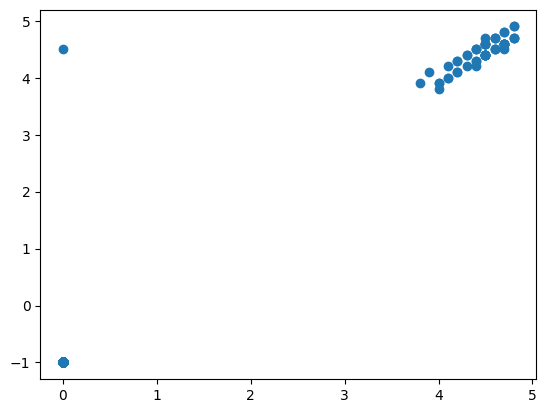

In [141]:
display(data[['Rating','Comp_Rating']][data['Rating']!=data['Comp_Rating']].count())
plt.scatter(data['Rating'][data['Rating']!=data['Comp_Rating']],data['Comp_Rating'][data['Rating']!=data['Comp_Rating']])
plt.show()

In [142]:
data[['Price','Comp_Price']][data['Comp_Price'] != data['Price']].count()

Price         11
Comp_Price    11
dtype: int64

In [143]:
data[['Number of Reviews','Comp_no.of.reviews']][data['Number of Reviews']!=data['Comp_no.of.reviews']].count()

Number of Reviews     1189
Comp_no.of.reviews    1190
dtype: int64

In [144]:
#11 price values are different than comp_price and 232 rating are different from comp_rating so it is decided to use the rating and price from the master dataset and also more values in number of reviews are different from comp_no.of.reviews
#Drop the Comp_Price,Comp_no.of.reviews
data.drop(['Comp_Price','Comp_Rating','Comp_no.of.reviews'],axis=1,inplace=True)

In [145]:
data = data[~(data['Description'].isnull())]

In [146]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1903 entries, 0 to 2912
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          1903 non-null   object 
 1   Author             1903 non-null   object 
 2   Rating             1903 non-null   float64
 3   Number of Reviews  1727 non-null   float64
 4   Price              1903 non-null   int64  
 5   Description        1903 non-null   object 
 6   Listening Time     1903 non-null   object 
 7   Ranks and Genre    1903 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 133.8+ KB


In [147]:
#Replacing missing values by mean value in the Number of reviews variables
data['Number of Reviews'] = data['Number of Reviews'].apply(lambda x: data['Number of Reviews'].mean() if pd.isnull(x) else x)

In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1903 entries, 0 to 2912
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          1903 non-null   object 
 1   Author             1903 non-null   object 
 2   Rating             1903 non-null   float64
 3   Number of Reviews  1903 non-null   float64
 4   Price              1903 non-null   int64  
 5   Description        1903 non-null   object 
 6   Listening Time     1903 non-null   object 
 7   Ranks and Genre    1903 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 133.8+ KB


In [149]:
#Check the outlier
def check_outlier(x,col_name):
    q1 = x.quantile(0.25)
    q2 = x.quantile(0.50)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    uf = q3 + 1.5*iqr
    lf = q1 - 1.5*iqr
    below = (x<=lf).sum()
    above = (x>=uf).sum()
    return col_name, below, above

In [150]:
for i in data.select_dtypes(include='number').columns:
    print(check_outlier(data[i],i))

('Rating', np.int64(243), np.int64(0))
('Number of Reviews', np.int64(0), np.int64(174))
('Price', np.int64(0), np.int64(108))


In [151]:
#Treat the outliers by replacing their mean values
#Rating
q1 = data['Rating'].quantile(0.25)
q3 = data['Rating'].quantile(0.75)
iqr = q3 - q1
lf = q1 - iqr*1.5
mean = data['Rating'].mean()
data.loc[data['Rating']<=lf,'Rating'] = mean
check_outlier(data['Rating'],'Rating')

('Rating', np.int64(0), np.int64(0))

In [152]:
#Number of Reviews
q1 = data['Number of Reviews'].quantile(0.25)
q3 = data['Number of Reviews'].quantile(0.75)
iqr = q3-q1
uf = q3 + iqr*1.5
rrmean = data['Number of Reviews'].mean()
data.loc[data['Number of Reviews']>=uf,'Number of Reviews']=rrmean
check_outlier(data['Number of Reviews'],'No.of Reviews')

('No.of Reviews', np.int64(0), np.int64(0))

In [153]:
#Price
q1 = data['Price'].quantile(0.25)
q3 = data['Price'].quantile(0.75)
iqr = q3-q1
uf = q3 + iqr*1.5
pmean = int(data['Price'].mean())
data.loc[data['Price']>=uf,'Price']=pmean
check_outlier(data['Number of Reviews'],'No.of Reviews')

('No.of Reviews', np.int64(0), np.int64(0))

In [154]:
data.to_csv('data.csv')

In [155]:
import re
pattern = r"#(\d+)\s+in\s+([^(]+)(?:\(([^)]+)\))?"

#Regex pattern explained:
#(\d+) → captures the rank number.
#\s+in\s+ → matches the word “in” with spaces.
#([^(]+) → captures the category name until a parenthesis.
#(?:\(([^)]+)\))? → optionally captures qualifier inside parentheses
results = []

for idx, raw_text in enumerate(data['Ranks and Genre']):
    entries = raw_text.split(',')
    for item in entries:
        item = item.strip()
        match = re.match(pattern,item)
        if match:
            rank = int(match.group(1))
            category = match.group(2).strip()
            qualifier = match.group(3)
            results.append({"row_index":idx,'genre':category,'rank':rank,'platform':qualifier})
df_1 = pd.DataFrame(results)
df_1.iloc[1760][['genre','rank']]

genre    Audible Audiobooks & Originals
rank                                671
Name: 1760, dtype: object

In [156]:
df_1['genre'] = df_1['genre'].replace("Audible Audiobooks & Originals",'Overall_rank')

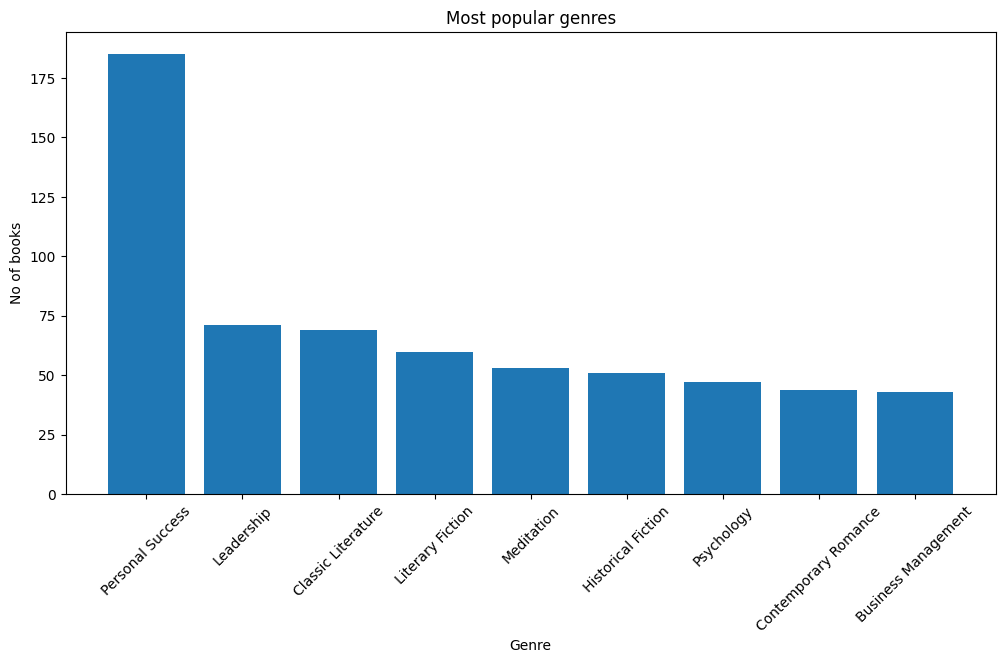

In [157]:
#Exploratory Data Analysis
#Q1. Most popular genres in the dataset
q1 = df_1['genre'].value_counts().reset_index()
q1 = q1[1:10]
fig = plt.subplots(figsize=(12,6))
plt.bar(q1['genre'],q1['count'])
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("No of books")
plt.title("Most popular genres")
plt.show()

In [158]:
def split_rank_genre(text):
    # Extract the very first "#number in ..." → overall rank
    first_match = re.search(r'#([\d,]+)\s+in', text)
    rank = None
    if first_match:
        rank = first_match.group(1).replace(',', '')  # clean commas
    
    # Extract all categories after "in"
    genres = re.findall(r'in\s+([^,]+)', text)
    
    # Clean and filter out non-genre entries
    genre_clean = []
    for g in genres:
        g = re.sub(r'\(.*?\)', '', g).strip()  # remove parentheses
        if "audible audiobooks" not in g.lower():  # skip platform labels
            genre_clean.append(g)
    
    # Always return exactly two values
    return pd.Series([rank, ",".join(genre_clean)])

data[['Rank','Genre']] = data['Ranks and Genre'].apply(split_rank_genre)

In [159]:
data['Genre'] = data['Genre'].apply(lambda x: ",".join(sorted([i.strip() for i in x.split(',') if i.strip()])))

In [160]:
#Normalizing 
def normalize_genre(name):
    name = name.lower().strip()
    name = re.sub(r'[^\w\s,]','',name)
    name = re.sub(r'\s+',' ',name)
    return name
data['Genre'] = data['Genre'].apply(normalize_genre)

In [161]:
data.iloc[1760][['Genre']]

Genre    contemporary romance,crime,erotic romance
Name: 2672, dtype: object

In [162]:
data['Author'] = data['Author'].str.lower()
def normalize_author(name):
    name = name.lower().strip()
    name = re.sub(r'[^\w\s]','',name)
    name = re.sub(r'\s+',' ',name)
    return name
data['Author'] = data['Author'].apply(normalize_author)
data['Book Name'] = data['Book Name'].apply(normalize_author)

In [163]:
def clean_text(text):
    if not isinstance(text,str):
        return ""
    text = text.lower()
    text = re.sub(r"'", "", text)
    token = word_tokenize(text)
    tokens = [t for t in token if t not in stopwords.words('english') and t not in string.punctuation]
    return " ".join(tokens)
data['Description'] = data['Description'].apply(clean_text)

In [164]:
data.isnull().sum()/data.shape[0]*100
#Rank variable is not used as it has more than 12% of missing values

Book Name            0.000000
Author               0.000000
Rating               0.000000
Number of Reviews    0.000000
Price                0.000000
Description          0.000000
Listening Time       0.000000
Ranks and Genre      0.000000
Rank                 1.944298
Genre                0.000000
dtype: float64

In [209]:
data = data[~(data['Rank'].isnull())]
data['Rank'] = data['Rank'].astype(int)
data['Number of Reviews'] = data['Number of Reviews'].astype(int)

In [166]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1866 entries, 0 to 2912
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          1866 non-null   object 
 1   Author             1866 non-null   object 
 2   Rating             1866 non-null   float64
 3   Number of Reviews  1866 non-null   float64
 4   Price              1866 non-null   int64  
 5   Description        1866 non-null   object 
 6   Listening Time     1866 non-null   object 
 7   Ranks and Genre    1866 non-null   object 
 8   Rank               1866 non-null   int64  
 9   Genre              1866 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 160.4+ KB


In [167]:
#Multilabel binarizer for genre
#data['Genre'] = data['Genre'].apply(lambda x: [i.strip() for i in x.split(',')])
#from sklearn.preprocessing import MultiLabelBinarizer
#mlb = MultiLabelBinarizer()
#genre_1 = mlb.fit_transform(data['Genre'])
#genre = pd.DataFrame(genre_1,columns=mlb.classes_)
#data_1 = pd.concat([data,genre],axis=1)

In [168]:
#genre.shape
#results in (1903,1591)

In [169]:
tf_genre = TfidfVectorizer()
genre_matrix = tf_genre.fit_transform(data['Genre'])

In [170]:
"""Sentence bert all-MiniLM-L6-v2 is a transformer model trained to produce a fixed length of vector (embedding) for any sentence regardless of the description variable is short or long
it outputs in a 384 dimensional vector. Each dimensions is a floating point number that encodes semantic information about the sentence. 
(model compressess the entire description into 384 dimensional array) but here convert_to_tensor=true convert the numpy array vector to pytorch tensor which is better for deeplearning
"""

'Sentence bert all-MiniLM-L6-v2 is a transformer model trained to produce a fixed length of vector (embedding) for any sentence regardless of the description variable is short or long\nit outputs in a 384 dimensional vector. Each dimensions is a floating point number that encodes semantic information about the sentence. \n(model compressess the entire description into 384 dimensional array) but here convert_to_tensor=true convert the numpy array vector to pytorch tensor which is better for deeplearning\n'

In [171]:
model = SentenceTransformer('all-MiniLM-L6-v2')
desc_matrix = model.encode(data['Description'].tolist(),convert_to_tensor = False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [172]:
x_scaler = StandardScaler()
numeric_scaled = x_scaler.fit_transform(data[['Rating','Number of Reviews','Rank','Price']])

In [173]:
#Kmeans clusterting - groups books into clusters based on overall similarity
#Cosine similarity - measures pairwise similarity between books (recommend book similar to this one eg books similar to science fiction, thrillers)

In [174]:
#Medium level
#Q1: Which books are frequently clustered together based on descriptions
kmean = KMeans(n_clusters = 10,random_state=42)
data['Cluster'] = kmean.fit_predict(desc_matrix)

In [175]:
for c in range(10):
    print(f"\nCluster {c}:")
    print(data[data['Cluster']==c][['Book Name','Genre']].head(5))


Cluster 0:
                                            Book Name  \
5                                             sapiens   
6                                             sapiens   
9   rich dad poor dad what the rich teach their ki...   
29     harry potter and the philosophers stone book 1   
31                          raavan enemy of aryavarta   

                                                Genre  
5   anthropology,anthropology,history of civilization  
6   anthropology,anthropology,history of civilization  
9   investing trading,personal development selfhel...  
29  family life fiction for children,fantasy magic...  
31                 epic fantasy,fantasy,fiction sagas  

Cluster 1:
                                           Book Name  \
7                           extraordinary leadership   
15  the alchemist a fable about following your dream   
19                                          becoming   
25                     the monk who sold his ferrari   
30   inglorious e

In [176]:
#Q2: How genre similarity affect book recommendations
genre_sim = cosine_similarity(genre_matrix)

In [177]:
book_index = 1
similar_index = genre_sim[book_index].argsort()[::-1][1:6]
print("Target Book:",data.iloc[book_index][['Book Name', 'Genre']])
print(data.iloc[similar_index][['Book Name','Genre']])

"""book_index = 0 - Selects the first book in the dataset that this is the target book you want recommendation for
genre_sim[book_index] - retrieves the similarity scores between the target book and all other books (each cosine score is a similarity 0 to 1)
argsort()[::-1] - sort the score in descending order (most similar first so we are reversing the order)
[1:6] - skips the first element [0] because that is the book itself (similarity = 1)
"""

Target Book: Book Name    ikigai the japanese secret to a long and happy...
Genre                   meditation,personal success,selfesteem
Name: 1, dtype: object
                                              Book Name  \
37    the rudest book ever insanely practical ideas ...   
1760  the 1 rule how to fall in love with the proces...   
2516                       the power of positive living   
1574  honoring the self the pyschology of confidence...   
1316  aapka bhavishya aapke haath mein forge your fu...   

                                                  Genre  
37    personal development selfhelp,personal success...  
1760  personal development selfhelp,personal success...  
2516  personal development selfhelp,personal success...  
1574                   mind,personal success,selfesteem  
1316                   mind,personal success,selfesteem  


'book_index = 0 - Selects the first book in the dataset that this is the target book you want recommendation for\ngenre_sim[book_index] - retrieves the similarity scores between the target book and all other books (each cosine score is a similarity 0 to 1)\nargsort()[::-1] - sort the score in descending order (most similar first so we are reversing the order)\n[1:6] - skips the first element [0] because that is the book itself (similarity = 1)\n'

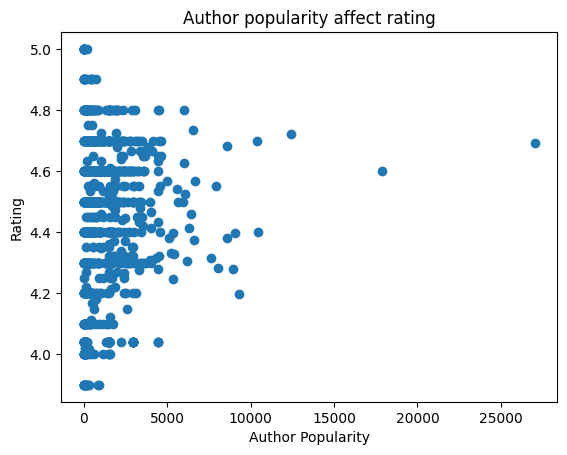

In [178]:
#Q3: How does the author popularity affect the rating
author_stats = data.groupby('Author').agg({
    'Number of Reviews':'sum',
    'Rating':'mean',
    'Book Name':'count'
})
plt.scatter(author_stats['Number of Reviews'],author_stats['Rating'])
plt.xlabel("Author Popularity")
plt.ylabel("Rating")
plt.title("Author popularity affect rating")
plt.show()

In [179]:
#Q4: Which combination of features provides the most accurate recommendations?
""" 
genre_matrix,desc_sparse,numeric_sparse,
"""
genre_sim = cosine_similarity(genre_matrix)
desc_sim = cosine_similarity(desc_matrix)

In [180]:
#Define a function to get the most similar books to the target based on the cosine similarity scores
def sim_book(sim_matrix,book_index,k=5):
    similar_indices=sim_matrix[book_index].argsort()[::-1][1:k+1]
    return similar_indices

In [181]:
#get all the books which share similar genre to the target book
def get_relevant_book(data,book_index):
    target_genre = set([g for g in data.iloc[book_index]['Genre'].split(',')])
    relevant_indices = []
    for idx,genres in enumerate(data['Genre']):
        book_genres = set([g.strip() for g in genres.split(',')])

        if target_genre & book_genres:
            relevant_indices.append(idx)
    return relevant_indices

In [182]:
#Predict the relvant books related to index 1 in the dataset
true = get_relevant_book(data,book_index=1)
pred = sim_book(genre_sim,book_index=1,k=5)
print("True value on cosine:",data.iloc[true][['Book Name','Genre']])
print("Prediction on cosine:",data.iloc[pred][['Book Name','Genre']])

True value on cosine:                                               Book Name  \
0     think like a monk the secret of how to harness...   
1     ikigai the japanese secret to a long and happy...   
2     the subtle art of not giving a fck a counterin...   
3     atomic habits an easy and proven way to build ...   
10      the 5am club own your morning elevate your life   
16                               thinking fast and slow   
26                  the power of your subconscious mind   
27      cant hurt me master your mind and defy the odds   
28    the power of habit why we do what we do and ho...   
34    limitless upgrade your brain learn anything fa...   
37    the rudest book ever insanely practical ideas ...   
77                everything is fcked a book about hope   
80    everything is figureoutable how one simple bel...   
85                         zen the art of simple living   
88           sochiye aur ameer baniye think and be rich   
89    tools of titans the tactics 

In [183]:
#Calculate the precision
def precision_at_k(pred,true,k=5):
    rec_tokens = set()
    for idx in pred[:k]:
        genres = data.iloc[idx]['Genre']
        rec_tokens.update([x.strip() for x in genres.split(',')])
    rel_tokens = set([x.strip() for x in true.split(",")])
    overlap = rec_tokens & rel_tokens
    return len(overlap)/k
#Calculate the recall
def recall_at_k(pred,true,k=5):
    rec_tokens = set()
    for idx in pred[:k]:
        genres = data.iloc[idx]['Genre']
        rec_tokens.update([x.strip() for x in genres.split(',')])
    rel_tokens = set([x.strip() for x in true.split(",")])
    overlap = rec_tokens & rel_tokens
    return len(overlap)/len(rel_tokens) if rel_tokens else 0
#Calculate the f1 score:
def f1_at_k(pred,true,k=5):
    p = precision_at_k(pred,true,k)
    r = recall_at_k(pred,true,k)
    return (2*p*r/(p+r)) if (p+r)>0 else 0

In [184]:
#Compute the precision for every book based on genre cosine similarity
precision =[]
for i in range(len(data)):
    pred = sim_book(genre_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = precision_at_k(pred,true,k=5)
    precision.append(p)
print(np.mean(precision))

recall =[]
for i in range(len(data)):
    pred = sim_book(genre_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = recall_at_k(pred,true,k=5)
    recall.append(p)
print(np.mean(recall))

f1 = []
for i in range(len(data)):
    pred = sim_book(genre_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = f1_at_k(pred,true,k=5)
    f1.append(p)
print(np.mean(f1))

0.4466237942122187
0.8407466952483029
0.5761241259633543


In [185]:
#Compute the precision for every book based on description cosine similarity
precision =[]
for i in range(len(data)):
    pred = sim_book(desc_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = precision_at_k(pred,true,k=5)
    precision.append(p)
print(np.mean(precision))

recall =[]
for i in range(len(data)):
    pred = sim_book(desc_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = recall_at_k(pred,true,k=5)
    recall.append(p)
print(np.mean(recall))

f1 = []
for i in range(len(data)):
    pred = sim_book(desc_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = f1_at_k(pred,true,k=5)
    f1.append(p)
print(np.mean(f1))

0.19978563772775992
0.385048231511254
0.25948680651253


In [186]:
#Combine the description and genre and calculate the cosine similarity
#Combine features
from scipy.sparse import hstack, csr_matrix
desc_sparse = csr_matrix(desc_matrix)
numeric_sparse = csr_matrix(numeric_scaled)
c1 = hstack([genre_matrix,desc_sparse])
c1_sim = cosine_similarity(c1)

In [187]:
precision =[]
for i in range(len(data)):
    pred = sim_book(c1_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = precision_at_k(pred,true,k=5)
    precision.append(p)
print(np.mean(precision))

recall =[]
for i in range(len(data)):
    pred = sim_book(c1_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = recall_at_k(pred,true,k=5)
    recall.append(p)
print(np.mean(recall))

f1 = []
for i in range(len(data)):
    pred = sim_book(c1_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = f1_at_k(pred,true,k=5)
    f1.append(p)
print(np.mean(f1))

0.434941050375134
0.8205609146123615
0.5614632777012198


In [188]:
#Combine description, genre, rating, number of reviews
combined_features = hstack([genre_matrix,desc_sparse,numeric_sparse])
c2_sim = cosine_similarity(combined_features)

In [189]:
precision =[]
for i in range(len(data)):
    pred = sim_book(c2_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = precision_at_k(pred,true,k=5)
    precision.append(p)
print(np.mean(precision))

recall =[]
for i in range(len(data)):
    pred = sim_book(c2_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = recall_at_k(pred,true,k=5)
    recall.append(p)
print(np.mean(recall))

f1 = []
for i in range(len(data)):
    pred = sim_book(c2_sim,i,k=5)
    true = data.iloc[i]['Genre']
    p = f1_at_k(pred,true,k=5)
    f1.append(p)
print(np.mean(f1))

0.28917470525187566
0.5609146123615577
0.37609095084979327


In [190]:
#Fit the Kmean algorithm and then do the cosine similarity
#Kmean cluster on the combined features(description, genre, rating, number of reviews, rank, price)
kmean_overall = KMeans(n_clusters = 10,random_state=42)
data['Cluster_overall'] = kmean_overall.fit_predict(combined_features)

In [191]:
#Calculating the cosine similarity inside each cluster
def hybrid_recommendations(data, sim_matrix, book_index, k=5):
    # Step 1: Find cluster of target book
    cluster_id = data.iloc[book_index]['Cluster_overall']
    
    # Step 2: Get all books in same cluster (excluding itself)
    cluster_books = data[data['Cluster_overall'] == cluster_id].index.tolist()
    cluster_books = [idx for idx in cluster_books if idx != book_index]
    
    # Step 3: Rank by cosine similarity inside the cluster
    sims = sim_matrix[book_index, cluster_books]
    top_indices = [cluster_books[i] for i in sims.argsort()[::-1][:k]]
    
    return top_indices

In [192]:
def precision_recall_f1_hybrid(data, sim_matrix, book_index, k=5):
    recommended = hybrid_recommendations(data, sim_matrix, book_index, k)
    relevant = get_relevant_book(data, book_index)  # your token-overlap function
    
    overlap = set(recommended) & set(relevant)
    precision = len(overlap) / len(recommended) if recommended else 0
    recall = len(overlap) / len(relevant) if relevant else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

In [194]:
data = data.reset_index(drop=True)

In [201]:
precisions, recalls, f1s = [], [], []
for i in range(len(data)):
    p, r, f1 = precision_recall_f1_hybrid(data, genre_sim, i, k=5)
    precisions.append(p); recalls.append(r); f1s.append(f1)

print("Hybrid Precision@5:", np.mean(precisions))
print("Hybrid Recall@5:", np.mean(recalls))
print("Hybrid F1@5:", np.mean(f1s))

Hybrid Precision@5: 0.7120042872454447
Hybrid Recall@5: 0.0860648700482672
Hybrid F1@5: 0.13530729003296915


In [208]:
with open("tf_genre.pkl","wb") as f:
    pickle.dump(tf_genre,f)
np.save('desc_embed.npy',desc_matrix)

In [204]:
with open("kmean_overall.pkl",'wb') as f:
    pickle.dump(KMeans,f)

np.save('genre_sim.npy',genre_sim)
data.to_csv("books with clusters.csv",index=False)

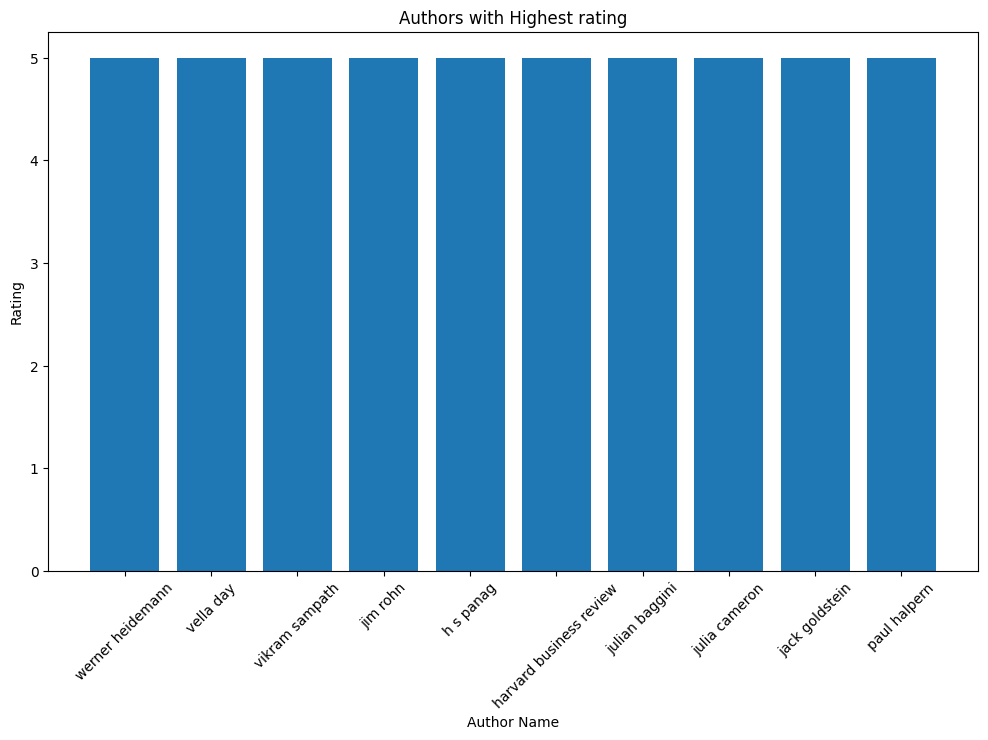

In [ ]:
#Q2: Which authors have the highest-rated books?
q2 = data.groupby('Author')['Rating'].max().reset_index()
q2 = q2.sort_values(by='Rating',ascending=False)
q2 = q2[0:10]
fig = plt.figure(figsize=(12,7))
plt.bar(q2['Author'],q2['Rating'])
plt.xticks(rotation=45)
plt.xlabel("Author Name")
plt.ylabel("Rating")
plt.title("Authors with Highest rating")
plt.show()

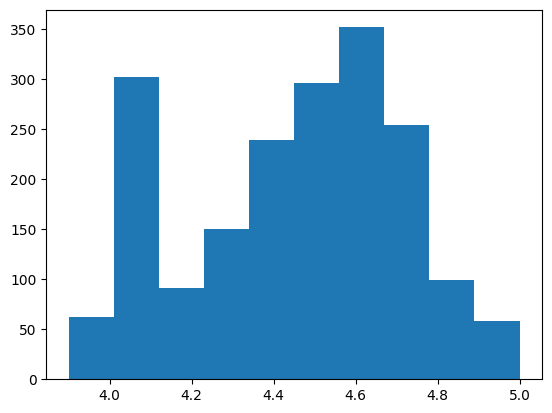

In [ ]:
#Q3:Average ratings across books
plt.hist(data['Rating'],bins=10)
plt.show()

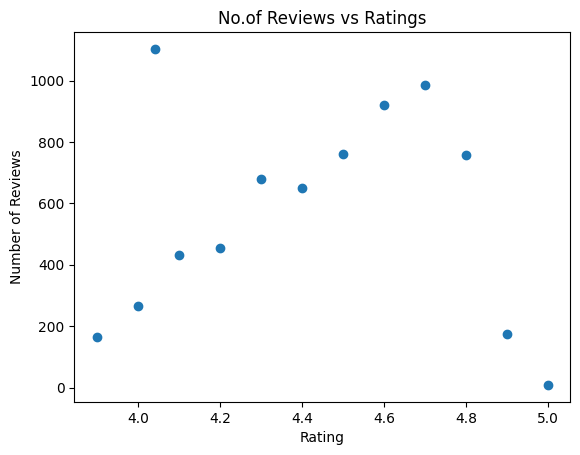

In [ ]:
#Q5: Ratings vary between number of reviews
q5 = data.groupby('Rating')['Number of Reviews'].mean().reset_index()
q5 = q5.sort_values(by='Number of Reviews')
plt.scatter(q5['Rating'],q5['Number of Reviews'])
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("No.of Reviews vs Ratings")
plt.show()